# Workflow for a multi-regional energy system with pooledCommodities for trading via a trading pool

In this application of the ETHOS.FINE framework, a multi-regional energy system is modeled and optimized, which uses pooledCommodities for trading within a trading pool.

All classes which are available to the user are utilized and examples of the selection of different parameters within these classes are given.

The workflow is structures as follows:
1. Required packages are imported and the input data path is set
2. An energy system model instance is created and pooledCommodities are defined
3. Commodity sources are added to the energy system model
4. Commodity conversion components are added to the energy system model
5. Commodity storages are added to the energy system model
6. Commodity Import and Export via Pooled Trade components are added to the energy system model
7. Commodity sinks are added to the energy system model
8. The energy system model is optimized
9. Selected optimization results are presented


# 1. Import required packages and set input data path

The ETHOS.FINE framework is imported which provides the required classes and functions for modeling the energy system.

In [120]:
import fine as fn
from getData import getData, INPUT_DATA_PATH
import pandas as pd
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

cwd = Path.cwd()
data = getData()

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Create an energy system model instance 

The structure of the energy system model is given by the considered locations, commodities, the number of time steps as well as the hours per time step.

The commodities are specified by a unit (i.e. 'GW_electric', 'GW_H2lowerHeatingValue', 'Mio. t CO2/h') which can be given as an energy or mass unit per hour. Furthermore, the cost unit and length unit are specified.

In [121]:
locations = {
    "cluster_0",
    "cluster_1",
    "cluster_2",
    "cluster_3",
    "cluster_4",
    "cluster_5",
    "cluster_6",
    "cluster_7",
}
commodityUnitDict = {
    "electricity": r"GW$_{el}$",
    "methane": r"GW$_{CH_{4},LHV}$",
    "biogas": r"GW$_{biogas,LHV}$",
    "CO2": r"Mio. t$_{CO_2}$/h",
    "hydrogen": r"GW$_{H_{2},LHV}$",
    "hydrogen_trade": r"GW$_{H_{2},LHV}$",
}

commodities = {"electricity", "hydrogen", "methane", "biogas", "CO2", "hydrogen_trade"}
numberOfTimeSteps = 8760
hoursPerTimeStep = 1

In [122]:
esM = fn.EnergySystemModel(
    locations=locations,
    commodities=commodities,
    numberOfTimeSteps=8760,
    commodityUnitsDict=commodityUnitDict,
    hoursPerTimeStep=1,
    costUnit="1e9 Euro",
    lengthUnit="km",
    verboseLogLevel=0,
    pooledCommodities={
        "hydrogen_trade": {
            "DE_hydrogen_pool_1": [
                "cluster_0",
                "cluster_1",
                "cluster_2",
                "cluster_3",
            ],
            "DE_hydrogen_pool_2": [
                "cluster_4",
                "cluster_5",
                "cluster_6",
                "cluster_7",
            ],
        }
    },
)

# 3. Add commodity sources to the energy system model

## 3.1. Electricity sources

### Wind onshore

In [123]:
esM.add(
    fn.Source(
        esM=esM,
        name="Wind (onshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (onshore), operationRateMax"],
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=1.1,
        opexPerCapacity=1.1 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
    )
)

### Wind offshore

In [124]:
esM.add(
    fn.Source(
        esM=esM,
        name="Wind (offshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (offshore), operationRateMax"],
        capacityMax=data["Wind (offshore), capacityMax"],
        investPerCapacity=2.3,
        opexPerCapacity=2.3 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
    )
)

### PV

In [125]:
esM.add(
    fn.Source(
        esM=esM,
        name="PV",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["PV, operationRateMax"],
        capacityMax=data["PV, capacityMax"],
        investPerCapacity=0.65,
        opexPerCapacity=0.65 * 0.02,
        interestRate=0.08,
        economicLifetime=25,
    )
)

# 4. Add conversion components to the energy system model

### New combined cycly gas turbines for hydrogen

In [126]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="New CCGT plants (hydrogen)",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": 1, "hydrogen": -1 / 0.63},
        hasCapacityVariable=True,
        investPerCapacity=0.7,
        opexPerCapacity=0.021,
        interestRate=0.08,
        economicLifetime=33,
    )
)

### Electrolyzers

In [127]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="Electrolyzer",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": -1, "hydrogen": 0.7},
        hasCapacityVariable=True,
        investPerCapacity=0.5,
        opexPerCapacity=0.5 * 0.025,
        interestRate=0.08,
        economicLifetime=10,
    )
)

# 5. Add commodity storages to the energy system model

## 5.1. Electricity storage

### Lithium ion batteries

The self discharge of a lithium ion battery is here described as 3% per month. The self discharge per hours is obtained using the equation (1-$\text{selfDischarge}_\text{hour})^{30*24\text{h}} = 1-\text{selfDischarge}_\text{month}$.

In [128]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Li-ion batteries",
        commodity="electricity",
        hasCapacityVariable=True,
        chargeEfficiency=0.95,
        cyclicLifetime=10000,
        dischargeEfficiency=0.95,
        selfDischarge=1 - (1 - 0.03) ** (1 / (30 * 24)),
        chargeRate=1,
        dischargeRate=1,
        doPreciseTsaModeling=False,
        investPerCapacity=0.151,
        opexPerCapacity=0.002,
        interestRate=0.08,
        economicLifetime=22,
    )
)

## 5.2. Hydrogen storage

### Hydrogen filled salt caverns
The maximum capacity is here obtained by: dividing the given capacity (which is given for methane) by the lower heating value of methane and then multiplying it with the lower heating value of hydrogen.

In [129]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Salt caverns (hydrogen)",
        commodity="hydrogen",
        hasCapacityVariable=True,
        capacityVariableDomain="continuous",
        capacityPerPlantUnit=133,
        chargeRate=1 / 470.37,
        dischargeRate=1 / 470.37,
        sharedPotentialID="Existing salt caverns",
        stateOfChargeMin=0.33,
        stateOfChargeMax=1,
        capacityMax=data["Salt caverns (hydrogen), capacityMax"],
        investPerCapacity=0.00011,
        opexPerCapacity=0.00057,
        interestRate=0.08,
        economicLifetime=30,
    )
)

# 6. Add commodity transmission components to the energy system model

## 6.1. Electricity transmission

### AC cables

esM.add(fn.LinearOptimalPowerFlow(esM=esM, name='AC cables', commodity='electricity',
                                  hasCapacityVariable=True, capacityFix=data['AC cables, capacityFix'],
                                  reactances=data['AC cables, reactances']))

In [130]:
esM.add(
    fn.Transmission(
        esM=esM,
        name="AC cables",
        commodity="electricity",
        hasCapacityVariable=True,
        capacityFix=data["AC cables, capacityFix"],
    )
)

### DC cables

In [131]:
esM.add(
    fn.Transmission(
        esM=esM,
        name="DC cables",
        commodity="electricity",
        losses=data["DC cables, losses"],
        distances=data["DC cables, distances"],
        hasCapacityVariable=True,
        capacityFix=data["DC cables, capacityFix"],
    )
)

## 6.3 Hydrogen transmission via Pooled Trade

### Hydrogen Export

In [132]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="hydrogen_exp",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"hydrogen": -1, "hydrogen_trade": 1},
        opexPerOperation=1.5e-5,
    )
)

### Hydrogen Import

In [133]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="hydrogen_imp",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"hydrogen_trade": -1, "hydrogen": 1},
        opexPerOperation=1.5e-5,
    )
)

# 7. Add commodity sinks to the energy system model

## 7.1. Electricity sinks

### Electricity demand

In [134]:
esM.add(
    fn.Sink(
        esM=esM,
        name="Electricity demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=data["Electricity demand, operationRateFix"],
    )
)

## 7.2. Hydrogen sinks

### Fuel cell electric vehicle (FCEV) demand

In [135]:
FCEV_penetration = 1
esM.add(
    fn.Sink(
        esM=esM,
        name="Hydrogen demand",
        commodity="hydrogen",
        hasCapacityVariable=False,
        operationRateFix=data["Hydrogen demand, operationRateFix"] * FCEV_penetration,
    )
)

All components are now added to the model and the model can be optimized. If the computational complexity of the optimization should be reduced, the time series data of the specified components can be clustered before the optimization and the parameter timeSeriesAggregation is set to True in the optimize call.

# 8 Temporal Aggregation

In [136]:
esM.aggregateTemporally(numberOfTypicalPeriods=7)

### Optimization

In [137]:
# The `optimizationSpecs` only work with the Gurobi solver. If you are using another solver you need to choose
# specs spcecific to this solver or no specs.
esM.optimize(
    timeSeriesAggregation=True,
    optimizationSpecs="OptimalityTol=1e-3 method=2 cuts=0 MIPGap=5e-3",
    solver=fn.utils.ImplementedSolvers.GUROBI.value,
)

Set parameter Threads to value 3
Set parameter LogFile to value ""
Set parameter OptimalityTol to value 0.001
Set parameter Method to value 2
Set parameter Cuts to value 0
Set parameter MIPGap to value 0.005
Set parameter QCPDual to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Rocky Linux 8.8 (Green Obsidian)")

CPU model: Intel(R) Xeon(R) Gold 6154 CPU @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 36 physical cores, 72 logical processors, using up to 3 threads

Non-default parameters:
MIPGap  0.005
OptimalityTol  0.001
Method  2
Cuts  0
TSPort  41955
QCPDual  1
Threads  3

Optimize a model with 34525 rows, 17591 columns and 98106 nonzeros (Min)
Model fingerprint: 0xea68390f
Model has 1393 linear objective coefficients
Coefficient statistics:
  Matrix range     [2e-08, 1e+04]
  Objective range  [4e-04, 3e-01]
  Bounds range     [3e-01, 3e+04]
  RHS range        [1e+00, 1e+00]

Presolve removed 14586 rows and 7639 columns
Presolve time: 0.06s
Pr

/fast/home/d-marmullaku/Projects/Hackathon_5/fine/fine/storage.py:2133: UserWarning: Charge and discharge at the same time for component Li-ion batteries
  warnings.warn(
/fast/home/d-marmullaku/Projects/Hackathon_5/fine/fine/storage.py:2133: UserWarning: Charge and discharge at the same time for component Salt caverns (hydrogen)
  warnings.warn(


# 9. Selected results output

Plot locations (GeoPandas required)

In [138]:
# Import the geopandas package for plotting the locations

In [139]:
locFilePath = INPUT_DATA_PATH / "SpatialData" / "ShapeFiles" / "clusteredRegions.shp"

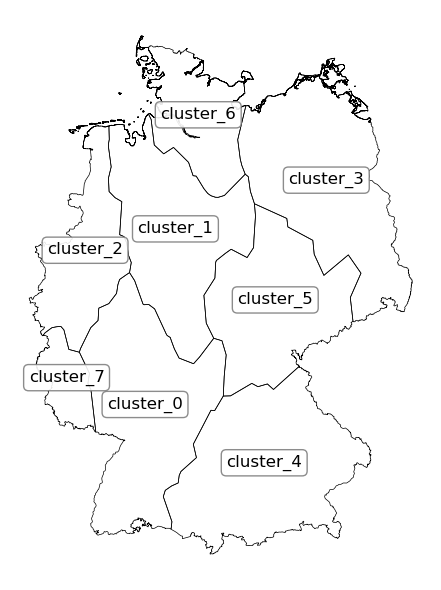

In [140]:
fig, ax = fn.plotLocations(locFilePath, plotLocNames=True, indexColumn="index")

### Sources and Sink

Show optimization summary

In [141]:
esM.getOptimizationSummary("SourceSinkModel", outputLevel=2)

cluster_0  \
Component          Property         Unit                                    
Electricity demand operation        [GW$_{el}$*h]           133963.451433   
                   operation_annual [GW$_{el}$*h/a]         133963.451433   
Hydrogen demand    operation        [GW$_{H_{2},LHV}$*h]     31710.458182   
                   operation_annual [GW$_{H_{2},LHV}$*h/a]   31710.458182   
PV                 NPVcontribution  [1e9 Euro]                   3.200554   
                   TAC              [1e9 Euro/a]                 3.200554   
                   capacity         [GW$_{el}$]                 43.314414   
                   capexCap         [1e9 Euro/a]                 2.637467   
                   commissioning    [GW$_{el}$]                 43.314414   
                   invest           [1e9 Euro]                  28.154369   
                   operation        [GW$_{el}$*h]            48159.521871   
                   operation_annual [GW$_{el}$*h/a]          48159.521871   
                   opexCap          [1e9 Euro/a]                 0.563087   
Wind (offshore)    NPVcontribution  [1e9 Euro]                          0   
                   TAC              [1e9 Euro/a]                        0   
                   capacity         [GW$_{el}$]                       NaN   
                   capexCap         [1e9 Euro/a]                      NaN   
                   commissioning    [GW$_{el}$]                       NaN   
                   invest           [1e9 Euro]                        NaN   
                   operation        [GW$_{el}$*h]                     NaN   
                   operation_annual [GW$_{el}$*h/a]                   NaN   
                   opexCap          [1e9 Euro/a]                      NaN   
Wind (onshore)     NPVcontribution  [1e9 Euro]                        0.0   
                   TAC              [1e9 Euro/a]                      0.0   
                   capacity         [GW$_{el}$]                       0.0   
                   capexCap         [1e9 Euro/a]                      0.0   
                   commissioning    [GW$_{el}$]                       0.0   
                   invest           [1e9 Euro]                        0.0   
                   operation        [GW$_{el}$*h]                     0.0   
                   operation_annual [GW$_{el}$*h/a]                   0.0   
                   opexCap          [1e9 Euro/a]                      0.0   

                                                               cluster_1  \
Component          Property         Unit                                   
Electricity demand operation        [GW$_{el}$*h]           66115.987455   
                   operation_annual [GW$_{el}$*h/a]         66115.987455   
Hydrogen demand    operation        [GW$_{H_{2},LHV}$*h]    22014.113765   
                   operation_annual [GW$_{H_{2},LHV}$*h/a]  22014.113765   
PV                 NPVcontribution  [1e9 Euro]                  1.909967   
                   TAC              [1e9 Euro/a]                1.909967   
                   capacity         [GW$_{el}$]                25.848365   
                   capexCap         [1e9 Euro/a]                1.573938   
                   commissioning    [GW$_{el}$]                25.848365   
                   invest           [1e9 Euro]                 16.801437   
                   operation        [GW$_{el}$*h]           23890.918405   
                   operation_annual [GW$_{el}$*h/a]         23890.918405   
                   opexCap          [1e9 Euro/a]                0.336029   
Wind (offshore)    NPVcontribution  [1e9 Euro]                   1.12104   
                   TAC              [1e9 Euro/a]                 1.12104   
                   capacity         [GW$_{el}$]                      4.0   
                   capexCap         [1e9 Euro/a]                 0.93704   
                   commissioning    [GW$_{el}$]                      4.0   
  

Plot installed capacities

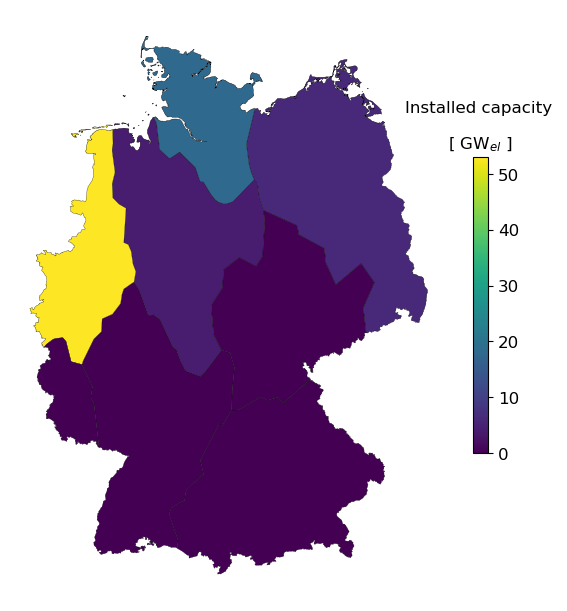

In [142]:
fig, ax = fn.plotLocationalColorMap(
    esM, "Wind (offshore)", locFilePath, "index", perArea=False
)

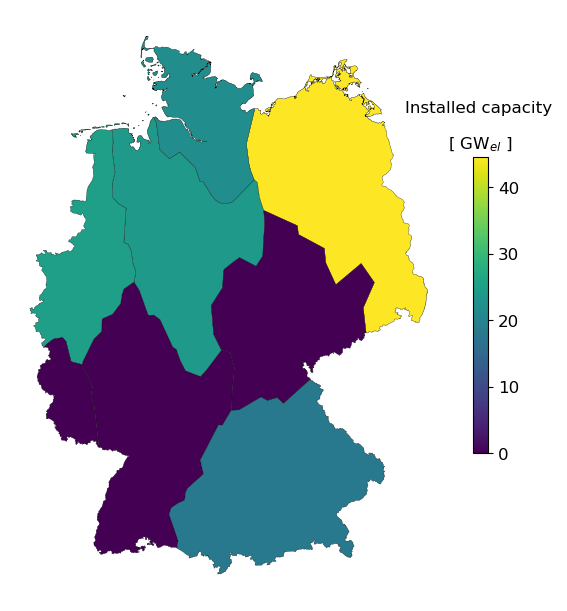

In [143]:
fig, ax = fn.plotLocationalColorMap(
    esM, "Wind (onshore)", locFilePath, "index", perArea=False
)

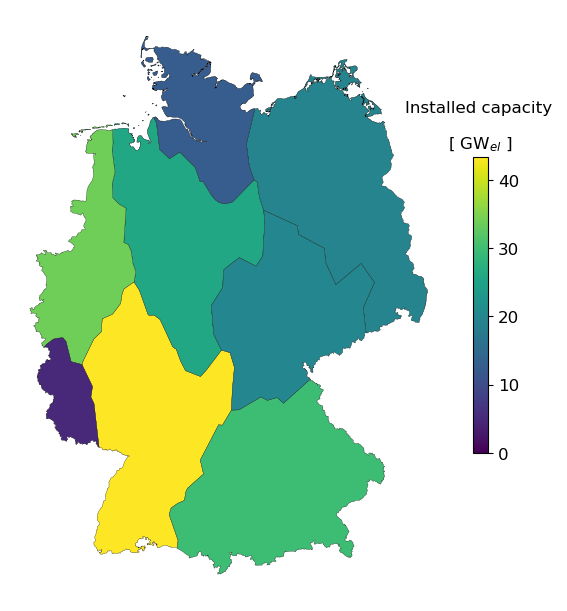

In [144]:
fig, ax = fn.plotLocationalColorMap(esM, "PV", locFilePath, "index", perArea=False)

### Conversion

Show optimization summary

In [145]:
esM.getOptimizationSummary("ConversionModel", outputLevel=2)

cluster_0     cluster_1  \
Component    Property         Unit                                          
Electrolyzer NPVcontribution  [1e9 Euro]            0.44998      1.095056   
             TAC              [1e9 Euro/a]          0.44998      1.095056   
             capacity         [GW$_{el}$]          5.171308     12.584719   
             capexCap         [1e9 Euro/a]         0.385339      0.937747   
             commissioning    [GW$_{el}$]          5.171308     12.584719   
             invest           [1e9 Euro]           2.585654      6.292359   
             operation        [GW$_{el}$*h]    33808.871557  35987.061868   
             operation_annual [GW$_{el}$*h/a]  33808.871557  35987.061868   
             opexCap          [1e9 Euro/a]         0.064641      0.157309   
hydrogen_exp NPVcontribution  [1e9 Euro]                0.0      0.047652   
             TAC              [1e9 Euro/a]              0.0      0.047652   
             capacity         [GW$_{el}$]               0.0      3.619915   
             commissioning    [GW$_{el}$]               0.0      3.619915   
             operation        [GW$_{el}$*h]             0.0   3176.829543   
             operation_annual [GW$_{el}$*h/a]           0.0   3176.829543   
             opexOp           [1e9 Euro/a]              0.0      0.047652   
hydrogen_imp NPVcontribution  [1e9 Euro]           0.120664           0.0   
             TAC              [1e9 Euro/a]         0.120664           0.0   
             capacity         [GW$_{el}$]          3.619915           0.0   
             commissioning    [GW$_{el}$]          3.619915           0.0   
             operation        [GW$_{el}$*h]     8044.248092           0.0   
             operation_annual [GW$_{el}$*h/a]   8044.248092           0.0   
             opexOp           [1e9 Euro/a]         0.120664           0.0   

                                                  cluster_2     cluster_3  \
Component    Property         Unit                                          
Electrolyzer NPVcontribution  [1e9 Euro]            1.43145       0.49543   
             TAC              [1e9 Euro/a]          1.43145       0.49543   
             capacity         [GW$_{el}$]         16.450659      5.693631   
             capexCap         [1e9 Euro/a]         1.225817      0.424259   
             commissioning    [GW$_{el}$]         16.450659      5.693631   
             invest           [1e9 Euro]           8.225329      2.846815   
             operation        [GW$_{el}$*h]    50340.302078  18660.943873   
             operation_annual [GW$_{el}$*h/a]  50340.302078  18660.943873   
             opexCap          [1e9 Euro/a]         0.205633       0.07117   
hydrogen_exp NPVcontribution  [1e9 Euro]           0.034995      0.038016   
             TAC              [1e9 Euro/a]         0.034995      0.038016   
             capacity         [GW$_{el}$]          3.619915      1.581828   
             commissioning    [GW$_{el}$]          3.619915      1.581828   
             operation        [GW$_{el}$*h]     2333.021567   2534.396982   
             operation_annual [GW$_{el}$*h/a]   2333.021567   2534.396982   
             opexOp           [1e9 Euro/a]         0.034995      0.038016   
hydrogen_imp NPVcontribution  [1e9 Euro]                0.0           0.0   
             TAC              [1e9 Euro/a]              0.0           0.0   
             capacity         [GW$_{el}$]               0.0           0.0   
             commissioning    [GW$_{el}$]               0.0           0.0   
             operation        [GW$_{el}$*h]             0.0           0.0   
             operation_annual [GW$_{el}$*h/a]           0.0           0.0   
             opexOp           [1e9 Euro/a]              0.0           0.0   

                                                  cluster_4     cluster_5  \
Component    Property         Unit                                          
Electrolyzer NPVcontribution  [1e9 Euro]    

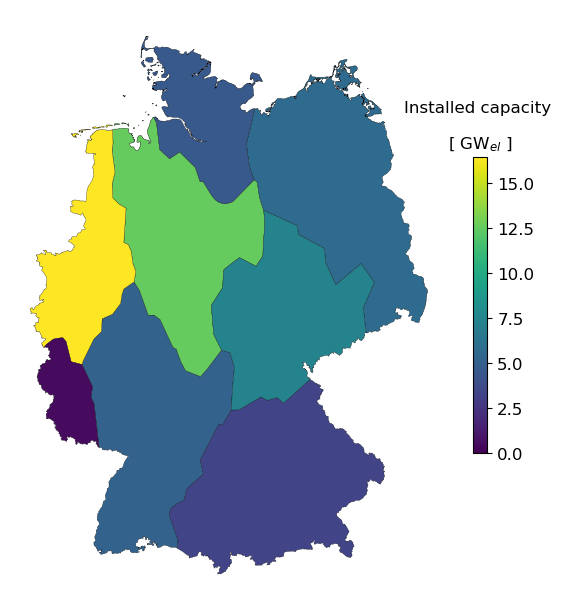

In [146]:
fig, ax = fn.plotLocationalColorMap(
    esM, "Electrolyzer", locFilePath, "index", perArea=False
)

Export

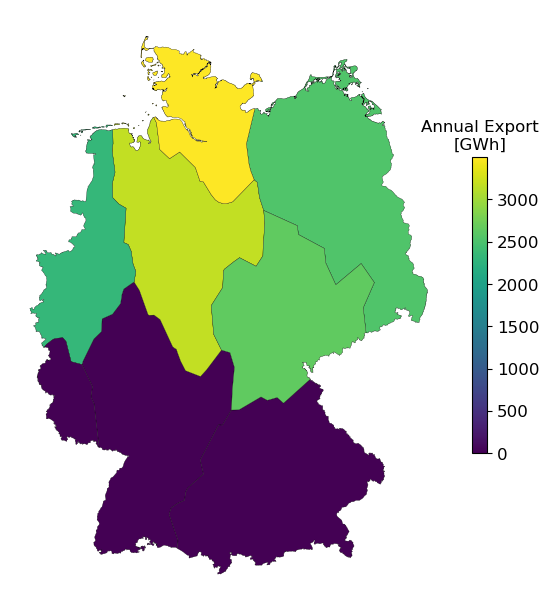

In [147]:
fig, ax = fn.plotLocationalColorMap(
    esM,
    "hydrogen_exp",
    locFilePath,
    "index",
    perArea=False,
    variableName="operationVariablesOptimum",
    doSum=True,
    zlabel="Annual Export [GWh]",
)

Import

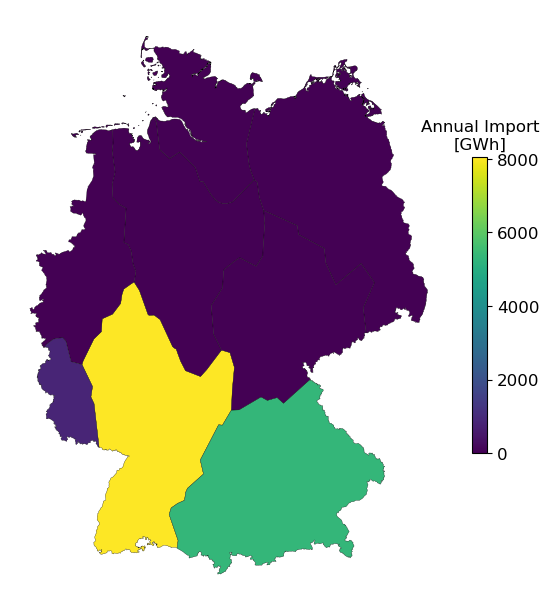

In [148]:
fig, ax = fn.plotLocationalColorMap(
    esM,
    "hydrogen_imp",
    locFilePath,
    "index",
    perArea=False,
    variableName="operationVariablesOptimum",
    doSum=True,
    zlabel="Annual Import [GWh]",
)

Trade

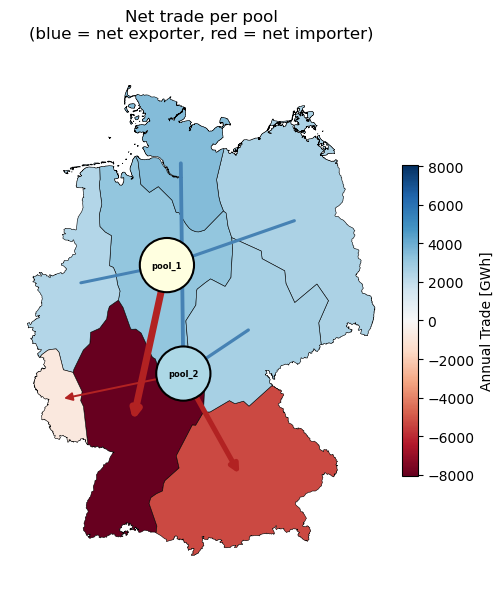

In [149]:
# ------------------------------------------------------------
# 1. Load spatial data
# ------------------------------------------------------------
gdf = gpd.read_file(locFilePath).to_crs("EPSG:3035").set_index("index")

# ------------------------------------------------------------
# 2. Get export/import operation values
# ------------------------------------------------------------
summary = esM.getOptimizationSummary("ConversionModel", outputLevel=2)
exp_op = summary.loc["hydrogen_exp"].loc["operation"].iloc[0]
imp_op = summary.loc["hydrogen_imp"].loc["operation"].iloc[0]

net_trade = exp_op - imp_op
gdf["net_trade"] = pd.to_numeric(
    net_trade.reindex(gdf.index).fillna(0), errors="coerce"
)

# ------------------------------------------------------------
# 3. Get pool membership from esM
# ------------------------------------------------------------
pools = esM.pooledCommodities["hydrogen_trade"]

# assign each region to its pool
cluster_to_pool = {
    cluster: pool_name for pool_name, clusters in pools.items() for cluster in clusters
}
gdf["pool"] = gdf.index.map(cluster_to_pool)

# ------------------------------------------------------------
# 4. Compute one pool node position per pool
# ------------------------------------------------------------
pool_colors = {
    pool_name: color
    for pool_name, color in zip(pools.keys(), ["lightyellow", "lightblue"])
}

pool_positions = {}
for pool_name, clusters in pools.items():
    member_centroids = gdf.loc[gdf.index.intersection(clusters), "geometry"].centroid
    pool_positions[pool_name] = (member_centroids.x.mean(), member_centroids.y.mean())

radius = 50000

# ------------------------------------------------------------
# 5. Color norm and base map
# ------------------------------------------------------------
max_abs_color = gdf["net_trade"].abs().max()
norm = TwoSlopeNorm(vmin=-max_abs_color, vcenter=0, vmax=max_abs_color)

fig, ax = plt.subplots(figsize=(6, 6))

gdf.plot(
    column="net_trade",
    cmap="RdBu",
    norm=norm,
    ax=ax,
    legend=False,
    edgecolor="black",
    linewidth=0.4,
    zorder=1,
)

sm = mpl.cm.ScalarMappable(cmap="RdBu", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, fraction=0.04, pad=0.02)
cbar.set_label("Annual Trade [GWh]")

# ------------------------------------------------------------
# 6. Draw arrows: each cluster -> its pool node
# ------------------------------------------------------------
pool_position_shift = {
    # shift the pools for better visualization
    list(pool_positions.keys())[0]: (0, 60000),
    list(pool_positions.keys())[1]: (0, -60000),
}

pool_positions_plot = {
    pool_name: (
        xy[0] + pool_position_shift.get(pool_name, (0, 0))[0],
        xy[1] + pool_position_shift.get(pool_name, (0, 0))[1],
    )
    for pool_name, xy in pool_positions.items()
}

max_abs = gdf["net_trade"].abs().max()

for idx, row in gdf.iterrows():
    trade = row["net_trade"]
    if abs(trade) < 1e-6:
        continue

    pool_name = cluster_to_pool.get(idx)
    if pool_name is None:
        continue

    pool_xy = pool_positions_plot[pool_name]
    c = row.geometry.centroid
    lw = 1 + 4 * abs(trade) / max_abs if max_abs > 0 else 1

    if trade > 0:  # net exporter: cluster -> pool
        ax.annotate(
            "",
            xy=pool_xy,
            xytext=(c.x, c.y),
            arrowprops=dict(
                arrowstyle="-|>", color="steelblue", lw=lw, mutation_scale=12
            ),
            zorder=4,
        )
    else:  # net importer: pool -> cluster
        ax.annotate(
            "",
            xy=(c.x, c.y),
            xytext=pool_xy,
            arrowprops=dict(
                arrowstyle="-|>", color="firebrick", lw=lw, mutation_scale=12
            ),
            zorder=4,
        )

# ------------------------------------------------------------
# 7. Draw pool circles and labels
# ------------------------------------------------------------
for pool_name, pool_xy in pool_positions_plot.items():
    ax.add_patch(
        plt.Circle(
            pool_xy,
            radius,
            fc=pool_colors[pool_name],
            ec="black",
            linewidth=1.5,
            zorder=5,
        )
    )
    label = "_".join(pool_name.split("_")[-2:])
    ax.text(
        *pool_xy,
        label,
        ha="center",
        va="center",
        fontsize=6,
        fontweight="bold",
        zorder=6,
    )

# ------------------------------------------------------------
# 8. Final formatting
# ------------------------------------------------------------
ax.set_title("Net trade per pool\n(blue = net exporter, red = net importer)")
ax.axis("off")
plt.tight_layout()
plt.show()